In [9]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Carregar a base Digits
digits = load_digits()
X = digits.data
y = digits.target

In [11]:
# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [12]:
# Padronizar os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Criar modelo Naive Bayes
naive_bayes = GaussianNB()

In [14]:
# Treinar o modelo
naive_bayes.fit(X_train, y_train)

GaussianNB()

In [15]:
# Avaliar o modelo
y_pred = naive_bayes.predict(X_test)

print(f"Acurácia com Naive Bayes: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação por Dígito:")
print(classification_report(y_test, y_pred))

Acurácia com Naive Bayes: 77.22%

Relatório de Classificação por Dígito:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        54
           1       0.53      0.84      0.65        55
           2       0.86      0.57      0.68        53
           3       1.00      0.44      0.61        55
           4       0.97      0.69      0.80        54
           5       0.93      0.91      0.92        55
           6       0.93      0.98      0.95        54
           7       0.75      0.98      0.85        54
           8       0.46      0.73      0.56        52
           9       0.88      0.69      0.77        54

    accuracy                           0.77       540
   macro avg       0.83      0.77      0.77       540
weighted avg       0.83      0.77      0.77       540



In [16]:
# Testar uma nova entrada
digito_entrada = X_test[0:1]
previsao = naive_bayes.predict(digito_entrada)

print(f"O dígito é: {previsao[0]}")

O dígito é: 1


In [17]:
# Gráfico Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

<Figure size 800x600 with 0 Axes>

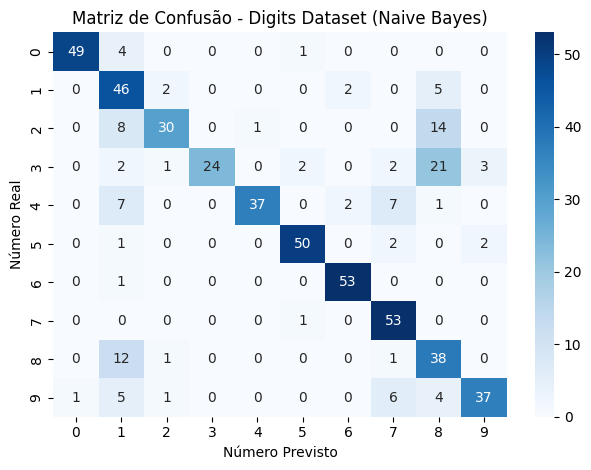

In [18]:
# Criar a matriz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(range(10)),
            yticklabels=list(range(10)))

plt.title('Matriz de Confusão - Digits Dataset (Naive Bayes)')
plt.ylabel('Número Real')
plt.xlabel('Número Previsto')
plt.tight_layout()
plt.show()